
# Week 3: Enterprise Analytics Hackathon: AdventureWorks
## Task 2 continued
This nb reads mainly from the `analytics.*` and `kpi.*` views built in `analytics_pipeline.sql`

## Lib and import Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4

#setting up the connection to the database
#PostgreSQL connection
DB_USER = "postgres"
DB_PASSWORD = "1234"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "AdventureWorks"

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

def q(sql):
    return pd.read_sql(sql, engine)  #using the required func

q("SELECT COUNT(*) AS sales_analytics_rows FROM analytics.sales_analytics")

,sales_analytics_rows
0,121317


## 1. Revenue Trend
Source: kpi.monthly_revenue

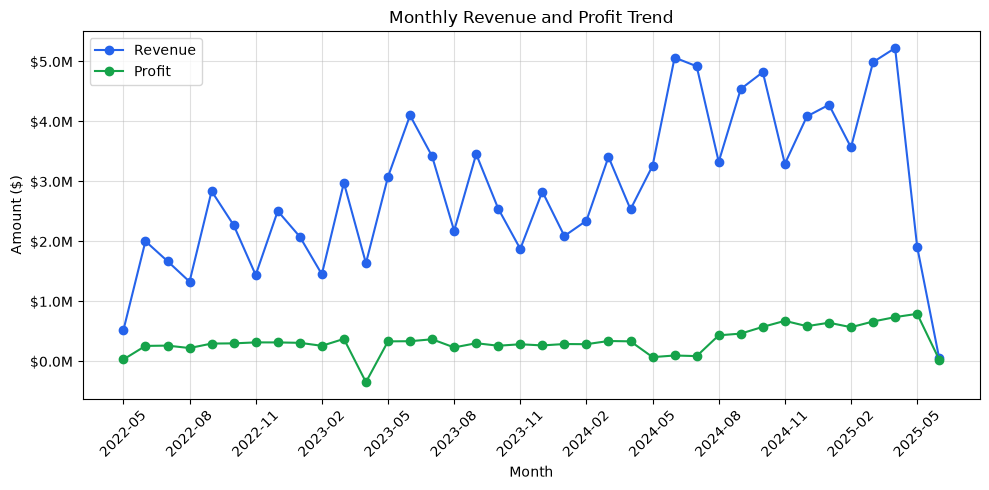

In [2]:
df_rev = q('''
    SELECT year, month, month_name, total_revenue, total_profit
    FROM kpi.monthly_revenue
    ORDER BY year, month
''')
df_rev['period'] = df_rev['year'].astype(str) + '-' + df_rev['month'].astype(str).str.zfill(2)

fig, ax = plt.subplots()
ax.plot(df_rev['period'], df_rev['total_revenue'], marker='o', label='Revenue', color='#2563eb')
ax.plot(df_rev['period'], df_rev['total_profit'], marker='o', label='Profit', color='#16a34a')
ax.set_title('Monthly Revenue and Profit Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Amount ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_xticks(ax.get_xticks()[::3])
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Noticed that the final months of the series fall in 2025, which is a partial year in this dataset (data ends June 2025), so any apparent drop at the right edge of the chart reflects incomplete data. That means there no actual decline, just not enough data for it.
The business should reference full calendar years only when discussing growth or decline when it comes to revenuw

## 2. Sales by Territory
Source: kpi.regional_revenue

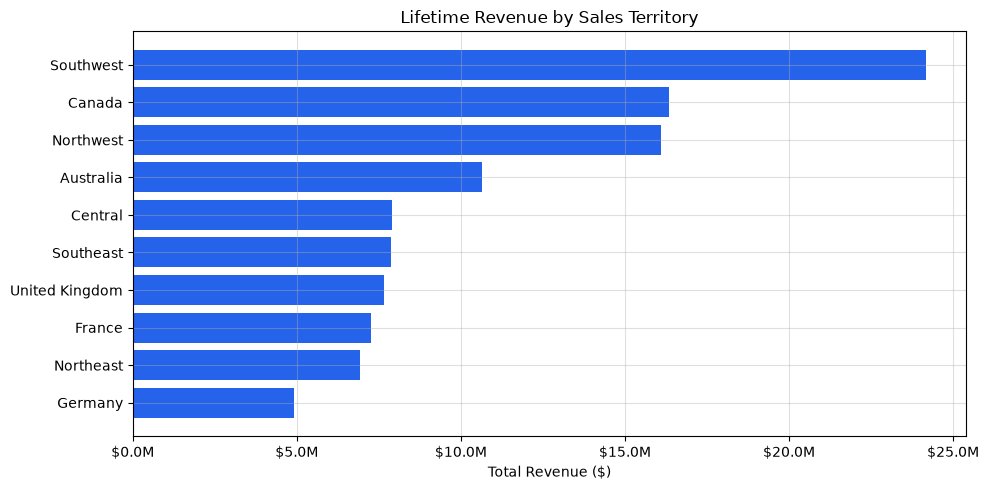

In [ ]:
df_terr = q('''
    SELECT territory_name, SUM(total_revenue) AS total_revenue
    FROM kpi.regional_revenue
    GROUP BY territory_name
    ORDER BY total_revenue DESC
''')

fig, ax = plt.subplots()
ax.barh(df_terr['territory_name'], df_terr['total_revenue'], color='#2563eb')
ax.set_title('Lifetime Revenue by Sales Territory')
ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** Revenue is pretty concentrated in a handful of territories The gap between the top and bottom territories is a very natural starting point for the recommendations we need to generate around regional investment

## 3. Customer Segments
Source: kpi.customer_segments

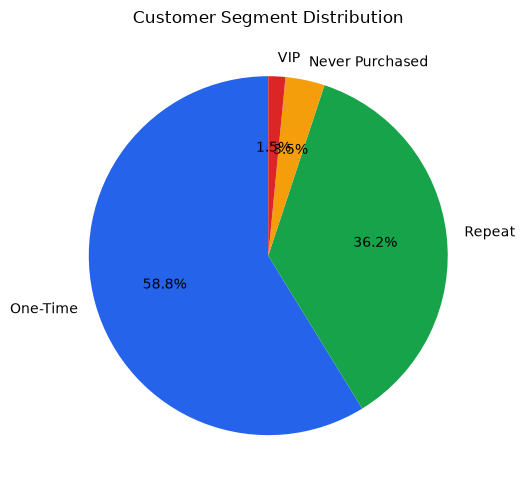

In [4]:
df_seg = q('''
    SELECT segment, COUNT(*) AS customer_count
    FROM kpi.customer_segments
    GROUP BY segment
    ORDER BY customer_count DESC
''')

fig, ax = plt.subplots()
colors = ['#2563eb', '#16a34a', '#f59e0b', '#dc2626']
ax.pie(df_seg['customer_count'], labels=df_seg['segment'], autopct='%1.1f%%',
       colors=colors[:len(df_seg)], startangle=90)
ax.set_title('Customer Segment Distribution')
plt.tight_layout()
plt.show()

**Insight:** All 3.5% "Never Purchased" customers here are store-channel (B2B) accounts, verified against analytics.customer_analytics. Theres no apparent error in the data. It would be worth investigating whether store orders are tracked through a different channel tho

## 4. Product Performance
Source: kpi.best_selling_products

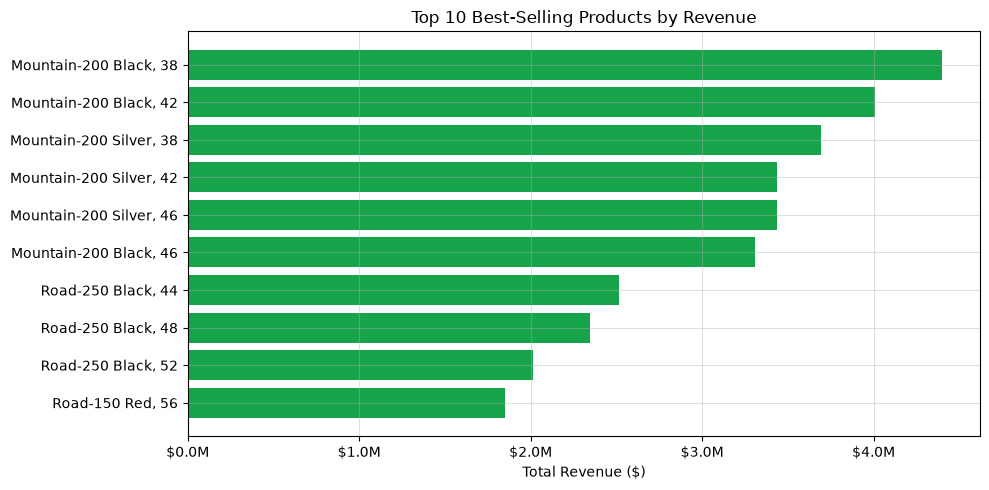

In [5]:
df_best = q("SELECT product_name, total_revenue FROM kpi.best_selling_products ORDER BY revenue_rank")

fig, ax = plt.subplots()
ax.barh(df_best['product_name'], df_best['total_revenue'], color='#16a34a')
ax.set_title('Top 10 Best-Selling Products by Revenue')
ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** high-end Mountain-200 bikes dominate the top of the list, both in price point and volume, suggesting the premium bike line is the primary revenue driver rather than accessories or lower-cost items

## 5. Category Revenue
Source: kpi.category_performance

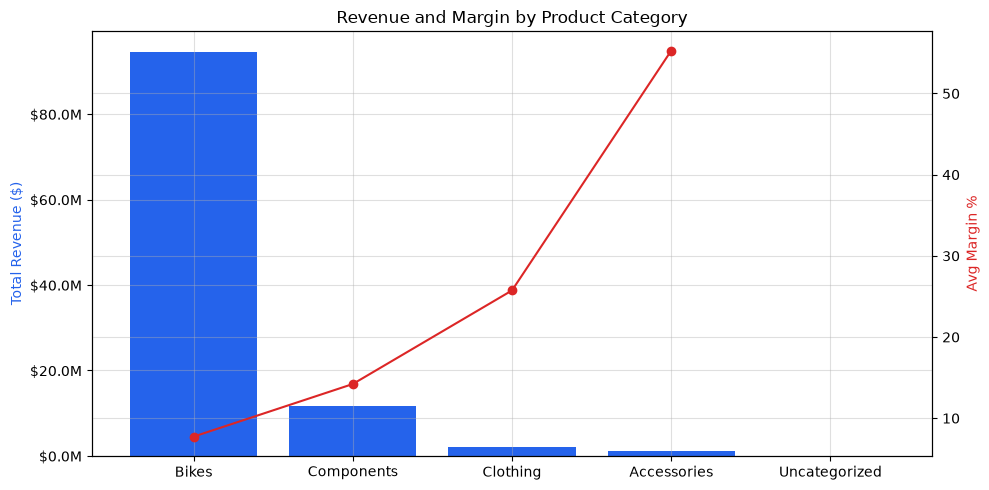

In [6]:
df_cat = q('''
    SELECT COALESCE(category_name, 'Uncategorized') AS category_name, total_revenue, avg_margin_pct
    FROM kpi.category_performance
    ORDER BY total_revenue DESC
''')

fig, ax1 = plt.subplots()
ax1.bar(df_cat['category_name'], df_cat['total_revenue'], color='#2563eb')
ax1.set_ylabel('Total Revenue ($)', color='#2563eb')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

ax2 = ax1.twinx()
ax2.plot(df_cat['category_name'], df_cat['avg_margin_pct'], color='#dc2626', marker='o')
ax2.set_ylabel('Avg Margin %', color='#dc2626')

ax1.set_title('Revenue and Margin by Product Category')
plt.tight_layout()
plt.show()

**Insight:** The "Uncategorized" group (209 products with no subcategory assigned in the source data) is excluded from margin comparison discussions since it's a data completeness gap, not a real business category.

**Observation**: Average margin starts to trend upwards when it comes to clothing and accessories, much more than their revenue

## 6. Employee Performance
Source: kpi.salesperson_rankings

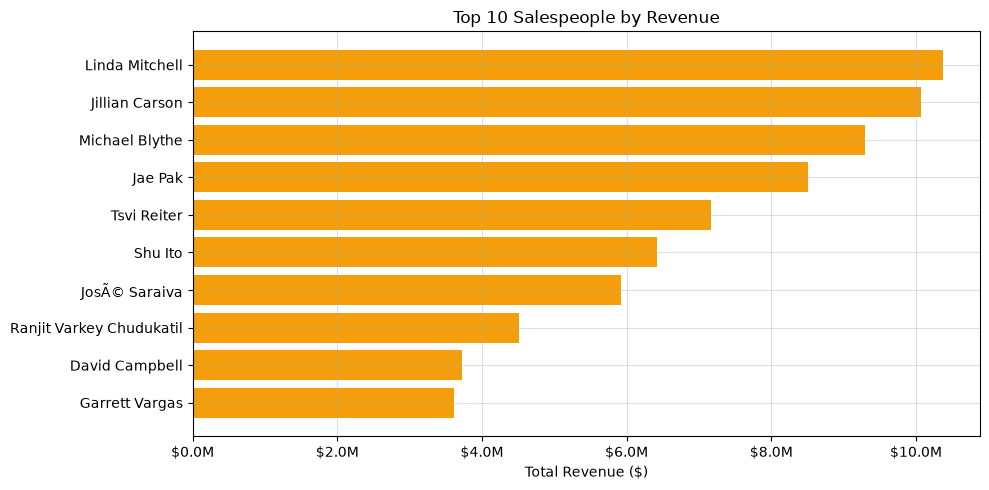

In [7]:
df_emp = q("SELECT employee_name, total_revenue FROM kpi.salesperson_rankings ORDER BY revenue_rank LIMIT 10")

fig, ax = plt.subplots()
ax.barh(df_emp['employee_name'], df_emp['total_revenue'], color='#f59e0b')
ax.set_title('Top 10 Salespeople by Revenue')
ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** A small group of salespeople account for a disproportionate share of revenue. If we cross ref with kpi.performance_comparison to see whether the same names are also exceeding their quotas, or whether quota-setting itself needs revisiting for the lower performers.

## 7. Inventory Status
Source:`kpi.inventory_health

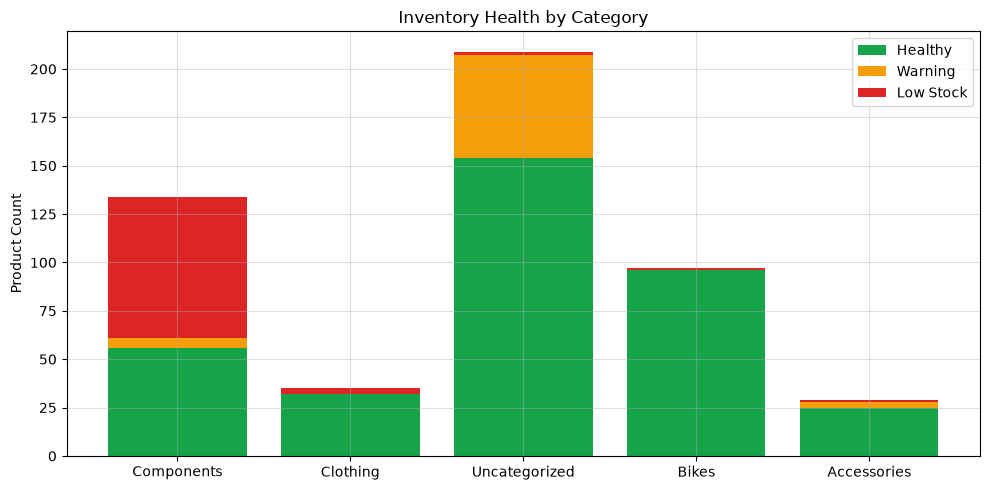

In [8]:
df_inv = q('''
    SELECT COALESCE(category_name, 'Uncategorized') AS category_name,
           low_stock_count, warning_count, healthy_count
    FROM kpi.inventory_health
    ORDER BY low_stock_count DESC
''')

fig, ax = plt.subplots()
ax.bar(df_inv['category_name'], df_inv['healthy_count'], label='Healthy', color='#16a34a')
ax.bar(df_inv['category_name'], df_inv['warning_count'], bottom=df_inv['healthy_count'],
       label='Warning', color='#f59e0b')
ax.bar(df_inv['category_name'], df_inv['low_stock_count'],
       bottom=df_inv['healthy_count'] + df_inv['warning_count'], label='Low Stock', color='#dc2626')
ax.set_title('Inventory Health by Category')
ax.set_ylabel('Product Count')
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** Categories with a large red segment are the ones to prioritize for reordering (mainly components) We should check with kpi.supplier_performance before choosing which vendor to place rush orders with.

## 8. Executive KPI Summary
Source: kpi.executive_summary

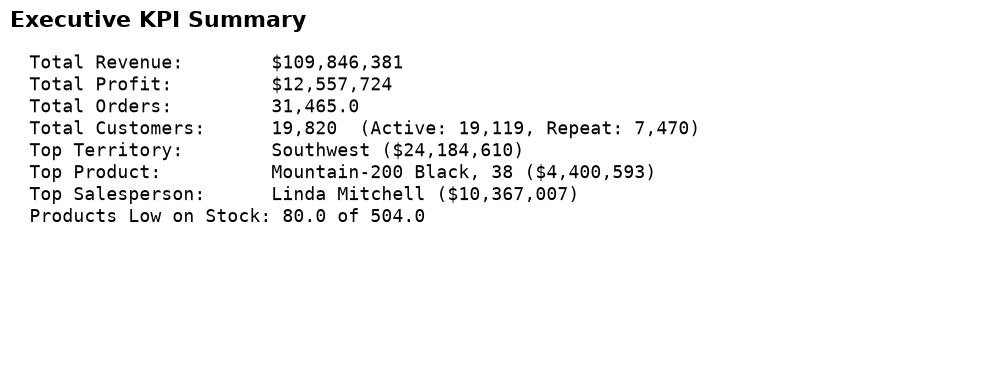

In [9]:
summary = q("SELECT * FROM kpi.executive_summary").iloc[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
kpi_text = (
    f"Total Revenue:        \${summary['total_revenue']:,.0f}\n"
    f"Total Profit:         \${summary['total_profit']:,.0f}\n"
    f"Total Orders:         {summary['total_orders']:,}\n"
    f"Total Customers:      {summary['total_customers']:,}  "
    f"(Active: {summary['active_customers']:,}, Repeat: {summary['repeat_customers']:,})\n"
    f"Top Territory:        {summary['top_territory_name']} "
    f"(\${summary['top_territory_revenue']:,.0f})\n"
    f"Top Product:          {summary['top_product_name']} "
    f"(\${summary['top_product_revenue']:,.0f})\n"
    f"Top Salesperson:      {summary['top_salesperson_name']} "
    f"(\${summary['top_salesperson_revenue']:,.0f})\n"
    f"Products Low on Stock: {summary['total_low_stock']} of {summary['total_products']}"
)
ax.text(0.02, 0.95, kpi_text, fontsize=13, va='top', family='monospace')
ax.set_title('Executive KPI Summary', fontsize=16, fontweight='bold', loc='left')
plt.tight_layout()
plt.show()

**Insight:** This single view chains across 6 KPI views monthly_revenue, customer_metrics, top_territories, best_selling_products,
salesperson_rankings, inventory_health to produce the headline numbers for leadership. Anyone extending the dashboard in the future only needs to read
from kpi.executive_summary not recompute any of this so we good

# Executive Recommendations

### Opportunities

1. Repeat customers are only 37% of customers but bring in almost 94% of revenue. Getting more one-time buyers to come back could make a big difference. See `kpi.customer_metrics`.
2. Accessories have the highest profit margin but much lower sales than Bikes. Bundling them with bike purchases is an easy way to increase profit. See `kpi.category_performance`.
3. Southwest, Canada, and Northwest generate over half of total revenue. We should use what works there to improve the other regions. See `kpi.regional_revenue` and `kpi.top_territories`.
4. International markets already contribute almost 28% of revenue, showing there's good potential to grow them further. See `kpi.regional_revenue`.
5. Every salesperson is beating their quota, so it's worth checking if the targets need to be updated. See `kpi.performance_comparison`.

### Risks

1. All store-channel (B2B) customers have zero recorded orders, which could mean missing data or a tracking issue. See `kpi.customer_segments`.
2. Around 16% of products are at or below their reorder point, increasing the risk of stockouts. See `kpi.low_stock_products`.
3. About 41% of products don't have a category assigned, making category reports incomplete. See `kpi.category_performance`.
4. The 2025 data only covers January to June, so comparisons with previous years can be misleading. See `kpi.monthly_revenue` and `kpi.regional_growth`.
5. Some suppliers have rejection rates close to 6%, which could become a quality problem. See `kpi.supplier_performance`.

### Recommendations

1. Focus on turning one-time buyers into repeat customers since repeat customers generate most of the revenue. See `kpi.customer_segments`.
2. Bundle accessories with bike purchases to increase profit per sale. See `kpi.category_performance`.
3. Apply the strategies from the top-performing regions to the weaker ones. See `kpi.regional_revenue`.
4. Review and increase sales quotas so they stay realistic and challenging. See `kpi.performance_comparison`.
5. Restock the highest-selling low-stock products first and review suppliers with high rejection rates. See `kpi.low_stock_products` and `kpi.supplier_performance`.
